# Strand B (coverage), extension: bounds with the Wayback fill

**Contribution:** `httparchive/07_coverage_bounds` tightened the coverage
interval by measuring ~63% of the unscanned visit mass with June-2022 HTTP
Archive data. This notebook adds a third layer: unscanned domains that only
Wayback captured get a fill calibrated on E[Blacklight count | Wayback
presence status], estimated on the calib_bl sample (domains with both a
Blacklight scan and a parsed snapshot). Only the still-never-measured visits
remain imputed by assumption.

All fills stay on the Blacklight scale; auxiliary sources contribute presence
information only. Scenario naming: `zero/mean/p90` (assumption only),
`ha_*` (HA fill), `hawb_*` (HA fill, then WB fill, remainder imputed).

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

import config
from utilities import pandas_to_tex, save_mpl_fig

MEASURES4 = [
    ("ddg_join_ads", "Ad trackers"),
    ("third_party_cookies", "Third-party cookies"),
    ("fb_pixel", "Facebook Pixel"),
    ("google_analytics", "Google Analytics"),
]
KEYS = [k for k, _ in MEASURES4]
# Wayback's static parse has no cookie visibility; its fill applies to the
# other three measures and third-party cookies falls back to HA-only fills.
WB_KEYS = ["ddg_join_ads", "fb_pixel", "google_analytics"]

Checking that all paths exist:
{'web_mobile': False, 'web_desktop': False, 'web': False, 'yg_profile': False, 'blacklight': False, 'who': False}


In [2]:
yg = pd.read_csv(config.FP_YG_IND_DOMAIN)
yg["filename"] = yg["private_domain"].str.replace(".", "_", regex=False)

bl = pd.read_csv(config.FP_BLACKLIGHT)
ha22 = (
    pd.read_csv(config.FP_HA_DOMAIN_MEASURES)
    .query("crawl == 'panel'")
    .groupby("private_domain")[KEYS]
    .mean()
)
wb = pd.read_csv(config.FP_WB_DOMAIN_MEASURES).set_index("private_domain")

merged = yg.merge(
    bl.rename(columns={k: f"bl_{k}" for k in bl.columns if k != "filename"}),
    on="filename", how="left",
).merge(ha22.add_prefix("ha_"), left_on="private_domain",
        right_index=True, how="left"
).merge(wb[WB_KEYS].add_prefix("wb_"), left_on="private_domain",
        right_index=True, how="left")

sample = pd.read_csv(
    os.path.join(config.DATA_DIR, "combined_yg_bl_who_derived_hist_tracking.csv"),
    usecols=["caseid"],
)["caseid"]

scanned = merged["bl_ddg_join_ads"].notna()
ha_measured = merged["ha_ddg_join_ads"].notna()
wb_measured = merged["wb_ddg_join_ads"].notna()

tot = merged["visits"].sum()
unsc = merged.loc[~scanned, "visits"].sum()
print(f"visits on unscanned domains                      : {100 * unsc / tot:.1f}%")
print(f"  measured by HA June 2022                       : "
      f"{100 * merged.loc[~scanned & ha_measured, 'visits'].sum() / unsc:.1f}%")
print(f"  measured only by Wayback                       : "
      f"{100 * merged.loc[~scanned & ~ha_measured & wb_measured, 'visits'].sum() / unsc:.1f}%")
print(f"  never measured                                 : "
      f"{100 * merged.loc[~scanned & ~ha_measured & ~wb_measured, 'visits'].sum() / unsc:.1f}%")

visits on unscanned domains                      : 23.6%
  measured by HA June 2022                       : 62.7%
  measured only by Wayback                       : 3.2%
  never measured                                 : 34.1%


In [3]:
def wmean(vals, w):
    return np.average(vals, weights=w) if len(vals) else 0.0


def wquantile(vals, w, q):
    order = np.argsort(vals)
    vals, w = np.asarray(vals)[order], np.asarray(w)[order]
    cw = np.cumsum(w) / np.sum(w)
    return vals[np.searchsorted(cw, q)]


tt_visits = merged.groupby("caseid")["visits"].sum()
w_all = merged["visits"]


def scenario_rates(k):
    """Mean per-user exposure rate for measure k under each scenario."""
    c_bl = merged[f"bl_{k}"]
    ha_present = merged[f"ha_{k}"] > 0

    fill_mean = wmean(c_bl[scanned], w_all[scanned])
    fill_p90 = wquantile(c_bl[scanned], w_all[scanned], 0.90)

    # HA calibration (as in 07_coverage_bounds)
    calib_ha_mask = scanned & ha_measured
    ha_m1 = wmean(c_bl[calib_ha_mask & ha_present], w_all[calib_ha_mask & ha_present])
    ha_m0 = wmean(c_bl[calib_ha_mask & ~ha_present], w_all[calib_ha_mask & ~ha_present])
    ha_fill = np.where(ha_present, ha_m1, ha_m0)

    # WB calibration on calib_bl domains (scanned & WB-parsed)
    if k in WB_KEYS:
        wb_present = merged[f"wb_{k}"] > 0
        calib_wb_mask = scanned & wb_measured
        wb_m1 = wmean(c_bl[calib_wb_mask & wb_present],
                      w_all[calib_wb_mask & wb_present])
        wb_m0 = wmean(c_bl[calib_wb_mask & ~wb_present],
                      w_all[calib_wb_mask & ~wb_present])
        wb_fill = np.where(wb_present, wb_m1, wb_m0)
    else:
        wb_fill = None

    def build(ha_layer, wb_layer, unmeasured_value):
        c = c_bl.copy()
        rest = ~scanned  # everything unscanned starts unmeasured
        if ha_layer:
            c[rest & ha_measured] = ha_fill[rest & ha_measured]
            rest = rest & ~ha_measured
        if wb_layer and wb_fill is not None:
            c[rest & wb_measured] = wb_fill[rest & wb_measured]
            rest = rest & ~wb_measured
        c[rest] = unmeasured_value
        return c

    scenarios = {
        "zero": build(False, False, 0.0),
        "mean": build(False, False, fill_mean),
        "p90": build(False, False, fill_p90),
        "ha_zero": build(True, False, 0.0),
        "ha_p90": build(True, False, fill_p90),
        "hawb_zero": build(True, True, 0.0),
        "hawb_mean": build(True, True, fill_mean),
        "hawb_p90": build(True, True, fill_p90),
    }
    out = {}
    for name, c in scenarios.items():
        user_rate = (c * merged["visits"]).groupby(merged["caseid"]).sum() / tt_visits
        out[name] = user_rate.reindex(sample).mean()
    return out


bounds = pd.DataFrame(
    {label: scenario_rates(k) for k, label in MEASURES4}
).T.reset_index(names="measure")
bounds.round(3)

,measure,zero,mean,p90,ha_zero,ha_p90,hawb_zero,hawb_mean,hawb_p90
0,Ad trackers,4.977,6.661,11.694,6.171,8.409,6.201,6.720,8.270
1,Third-party cookies,6.120,8.106,13.353,7.561,9.972,7.561,8.223,9.972
2,Facebook Pixel,0.083,0.106,0.083,0.097,0.097,0.098,0.105,0.098
3,Google Analytics,0.010,0.012,0.010,0.011,0.011,0.011,0.012,0.011


In [4]:
SCEN = ["zero", "mean", "p90", "ha_zero", "ha_p90",
        "hawb_zero", "hawb_mean", "hawb_p90"]
tex = bounds[["measure"] + SCEN].copy()
for c in SCEN:
    tex[c] = tex[c].map("{:.3f}".format)
pandas_to_tex(tex, os.path.join(config.TABLES_DIR, "coverage_bounds_wayback"))
print("wrote tables/coverage_bounds_wayback.tex")

wrote tables/coverage_bounds_wayback.tex


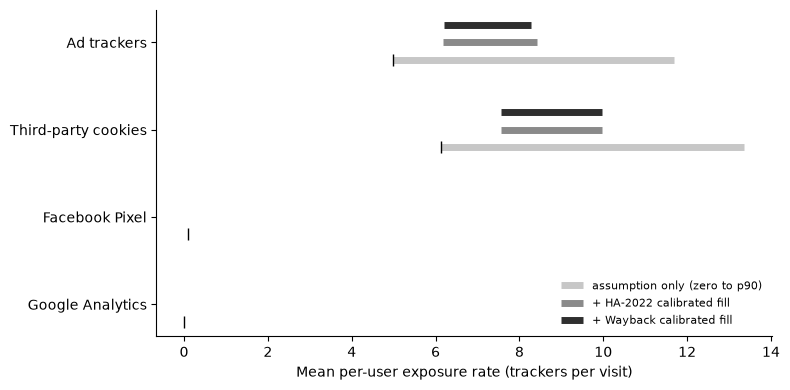

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(bounds))
ax.hlines(y + 0.2, bounds["zero"], bounds["p90"], color="#c7c7c7", lw=5,
          label="assumption only (zero to p90)")
ax.hlines(y, bounds["ha_zero"], bounds["ha_p90"], color="#8a8a8a", lw=5,
          label="+ HA-2022 calibrated fill")
ax.hlines(y - 0.2, bounds["hawb_zero"], bounds["hawb_p90"], color="#2f2f2f",
          lw=5, label="+ Wayback calibrated fill")
ax.plot(bounds["zero"], y + 0.2, "|", color="#000000", ms=9)
ax.set_yticks(y)
ax.set_yticklabels(bounds["measure"])
ax.set_xlabel("Mean per-user exposure rate (trackers per visit)")
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
ax.legend(frameon=False, loc="lower right", fontsize=8)
plt.tight_layout()
save_mpl_fig(os.path.join(config.FIGURES_DIR, "coverage_bounds_wayback"))
plt.show()

## Reading the results

Each successive interval uses less assumption and more measurement. The
`hawb_zero`–`hawb_p90` spread is driven only by visits that neither
Blacklight, HTTP Archive, nor Wayback could measure; its width relative to
the estimate is the residual uncertainty the coverage critique can still
claim. For third-party cookies the WB layer adds nothing (static HTML shows
no cookie behavior), so its `hawb_*` values equal the `ha_*` ones by
construction. Read the WB fill's credibility off `04_wb_ha_agreement` — if
recall was near zero for a measure, treat its `hawb_*` tightening as
assumption-like rather than measured.